In [1]:
"""
dataset.py — Dual-stream JunctionDataset
Returns (rgb_tensor, mask_tensor, label) per sample.

Folder layout expected:
  train/
    train_frames/          ← RGB .png  → fed to SegFormer branch
    train_masks/color/     ← colour segmentation .png → fed to CNN branch
    train_encoded.xlsx     ← col 0 = filename,  col 1 = label string
  val/  (same structure)
  test/ (same structure)

Key design decision — Joint Transforms:
  RGB and mask MUST receive identical geometric transforms (flip, affine)
  so that a flipped road image still aligns with its flipped mask.
  Colour jitter is applied ONLY to the RGB branch (masks use fixed colours
  that encode semantic class — jittering them destroys that information).
"""

import os
import random
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler


# ── Label map ─────────────────────────────────────────────────────────
LABEL_MAP  = {"No junction": 0, "T-junction": 1, "X-junction": 2}
CLASS_NAMES = ["No junction", "T-junction", "X-junction"]

# ── Normalisation ─────────────────────────────────────────────────────
# ImageNet stats for RGB branch (SegFormer pretrained with these)
_RGB_MEAN = [0.485, 0.456, 0.406]
_RGB_STD  = [0.229, 0.224, 0.225]

# Mask branch: simple 0-1 normalisation — pixel values encode class colour,
# not photometric intensity, so ImageNet stats would be misleading.
_MASK_MEAN = [0.5, 0.5, 0.5]
_MASK_STD  = [0.5, 0.5, 0.5]


# ══════════════════════════════════════════════════════════════════════
#  JOINT TRANSFORM
#  Applies the SAME geometric ops to both RGB and mask.
#  Applies colour jitter ONLY to RGB.
# ══════════════════════════════════════════════════════════════════════
class JointTransform:
    """
    Paired augmentation for (rgb_image, mask_image).

    Geometric transforms (flip, affine) → applied identically to both.
    Colour transforms (jitter, grayscale) → applied to RGB only.
    Resize → applied to both (deterministic, always safe).
    """

    def __init__(self, img_size: int = 384, split: str = "train"):
        self.img_size = img_size
        self.split    = split

        # Colour augmentation for RGB branch only
        self.rgb_color = T.Compose([
            T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
            T.RandomGrayscale(p=0.05),
        ])

        # Final tensor conversion + normalisation (applied separately per branch)
        self.rgb_to_tensor  = T.Compose([
            T.ToTensor(),
            T.Normalize(_RGB_MEAN,  _RGB_STD),
        ])
        self.mask_to_tensor = T.Compose([
            T.ToTensor(),
            T.Normalize(_MASK_MEAN, _MASK_STD),
        ])

        # Random erasing on tensor (RGB only, after normalisation)
        self.rgb_erasing = T.RandomErasing(
            p=0.15, scale=(0.02, 0.08), ratio=(0.5, 2.0)
        )

    def __call__(self, rgb: Image.Image, mask: Image.Image):
        # ── 1. Deterministic resize (both) ────────────────────────
        rgb  = TF.resize(rgb,  [self.img_size, self.img_size])
        mask = TF.resize(mask, [self.img_size, self.img_size],
                         interpolation=TF.InterpolationMode.NEAREST)
        # NEAREST interpolation for mask: prevents colour mixing at borders
        # which would create pixels with no valid semantic meaning.

        if self.split == "train":
            # ── 2. Random horizontal flip (both, same decision) ───
            if random.random() > 0.5:
                rgb  = TF.hflip(rgb)
                mask = TF.hflip(mask)

            # ── 3. Random affine (both, same params) ──────────────
            angle, translate, scale, shear = T.RandomAffine.get_params(
                degrees=(-5, 5),
                translate=(0.04, 0.04),
                scale_ranges=(0.95, 1.05),
                shears=None,
                img_size=[self.img_size, self.img_size],
            )
            rgb  = TF.affine(rgb,  angle, translate, scale, shear)
            mask = TF.affine(mask, angle, translate, scale, shear,
                             interpolation=TF.InterpolationMode.NEAREST)

            # ── 4. Colour jitter — RGB only ───────────────────────
            rgb = self.rgb_color(rgb)

        # ── 5. To tensor + normalise ──────────────────────────────
        rgb_t  = self.rgb_to_tensor(rgb)
        mask_t = self.mask_to_tensor(mask)

        # ── 6. Random erasing — RGB tensor only ───────────────────
        if self.split == "train":
            rgb_t = self.rgb_erasing(rgb_t)

        return rgb_t, mask_t


# ══════════════════════════════════════════════════════════════════════
#  DATASET
# ══════════════════════════════════════════════════════════════════════
class JunctionDataset(Dataset):
    """
    Dual-stream dataset. Returns (rgb_tensor, mask_tensor, label).

    Args:
        excel_path   : Path to *_encoded.xlsx
        rgb_dir      : train_frames/  or  val_frames/
        mask_dir     : train_masks/color/  or  val_masks/color/
        split        : 'train' | 'val' | 'test'
        img_size     : Square resize target (default 384 for RTX 4050)
    """

    def __init__(
        self,
        excel_path : str,
        rgb_dir    : str,
        mask_dir   : str,
        split      : str = "train",
        img_size   : int = 384,
    ):
        self.df       = pd.read_excel(excel_path)
        self.rgb_dir  = rgb_dir
        self.mask_dir = mask_dir
        self.split    = split
        self.transform = JointTransform(img_size=img_size, split=split)

        # Pre-compute labels for sampler
        self._labels = [
            LABEL_MAP[str(self.df.iloc[i, 1]).strip()]
            for i in range(len(self.df))
        ]

    def __len__(self) -> int:
        return len(self.df)

    def _load_img(self, directory: str, raw_filename: str, ext: str = ".png") -> Image.Image:
        """Strip extension from Excel entry and force the specified extension."""
        base = os.path.splitext(str(raw_filename))[0]
        path = os.path.join(directory, base + ext) # Uses the passed extension (.jpg or .png)
        try:
            return Image.open(path).convert("RGB")
        except FileNotFoundError:
            raise FileNotFoundError(
                f"\nFile not found: {path}"
                f"\nCheck that the directory '{directory}' is correct and files are {ext}."
            )
    def __getitem__(self, idx: int):
        row      = self.df.iloc[idx]
        filename = str(row.iloc[0])
        label    = LABEL_MAP[str(row.iloc[1]).strip()]

        # Specify extensions here:
        rgb  = self._load_img(self.rgb_dir,  filename, ext=".jpg") # RGB is .jpg
        mask = self._load_img(self.mask_dir, filename, ext=".png") # Mask is .png

        rgb_t, mask_t = self.transform(rgb, mask)
        return rgb_t, mask_t, label

    # ── Class balance helpers ─────────────────────────────────────
    def class_counts(self) -> list:
        from collections import Counter
        c = Counter(self._labels)
        return [c.get(i, 0) for i in range(len(LABEL_MAP))]

    def sample_weights(self) -> torch.Tensor:
        counts  = self.class_counts()
        inv     = [1.0 / max(c, 1) for c in counts]
        weights = [inv[lbl] for lbl in self._labels]
        return torch.tensor(weights, dtype=torch.float32)


# ══════════════════════════════════════════════════════════════════════
#  DATALOADER FACTORY
# ══════════════════════════════════════════════════════════════════════
def build_dataloaders(
    train_excel    : str,
    train_rgb_dir  : str,
    train_mask_dir : str,
    val_excel      : str,
    val_rgb_dir    : str,
    val_mask_dir   : str,
    batch_size     : int  = 4,
    img_size       : int  = 384,
    num_workers    : int  = 4,
    use_sampler    : bool = False,   # ← NEW: False = rely on focal loss alpha only
):
    """
    use_sampler=True   → WeightedRandomSampler balances batches + Focal Loss
                         (the previous behaviour — caused T-junction over-prediction)
    use_sampler=False  → Standard shuffle + Focal Loss alpha only (recommended)
    """
    train_ds = JunctionDataset(train_excel, train_rgb_dir, train_mask_dir,
                               split="train", img_size=img_size)
    val_ds   = JunctionDataset(val_excel,   val_rgb_dir,   val_mask_dir,
                               split="val",   img_size=img_size)
 
    if use_sampler:
        sampler      = WeightedRandomSampler(train_ds.sample_weights(),
                                             len(train_ds), replacement=True)
        train_loader = DataLoader(
            train_ds, batch_size=batch_size, sampler=sampler,
            num_workers=num_workers, pin_memory=True, drop_last=True,
            persistent_workers=(num_workers > 0),
        )
        print("[Dataset] Using WeightedRandomSampler (+ focal loss)")
    else:
        train_loader = DataLoader(
            train_ds, batch_size=batch_size, shuffle=True,
            num_workers=num_workers, pin_memory=True, drop_last=True,
            persistent_workers=(num_workers > 0),
        )
        print("[Dataset] Shuffle only — focal loss alpha handles imbalance")
 
    val_loader = DataLoader(
        val_ds, batch_size=batch_size * 2, shuffle=False,
        num_workers=num_workers, pin_memory=True,
        persistent_workers=(num_workers > 0),
    )
 
    print(f"[Dataset] Train : {len(train_ds):,} | Val : {len(val_ds):,}")
    print(f"[Dataset] Train class counts (No/T/X): {train_ds.class_counts()}")
    print(f"[Dataset]   Val class counts (No/T/X): {val_ds.class_counts()}")
    return train_loader, val_loader

Losses

In [2]:
"""
losses.py — Focal Loss for imbalanced multi-class classification

Focal Loss: FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

  alpha_t  : per-class weight — inverse class frequency (normalised)
             Penalises the dominant "No junction" class less, minority classes more
  gamma    : focusing parameter — down-weights easy/confident examples
             gamma=2 is the original paper default (Lin et al., 2017)
  p_t      : model's estimated probability for the true class

Combined with WeightedRandomSampler in the DataLoader, this gives a
double defense against class imbalance:
  1. Sampler level  → balanced batch composition
  2. Loss level     → hard-example mining within each batch
"""

import torch
import torch.nn as nn
import torch.nn.functional as F


class FocalLoss(nn.Module):
    """
    Multi-class focal loss.

    Args:
        alpha     : (num_classes,) per-class weights. Typically set to
                    inverse normalised class frequency.
        gamma     : Focusing exponent. 0 → standard cross-entropy.
        reduction : 'mean' | 'sum' | 'none'
    """

    def __init__(
        self,
        alpha: torch.Tensor,
        gamma: float = 2.0,
        reduction: str = "mean",
    ):
        super().__init__()
        # register_buffer → moves with .to(device), saved in state_dict
        self.register_buffer("alpha", alpha.float())
        self.gamma     = gamma
        self.reduction = reduction

    def forward(
        self,
        logits: torch.Tensor,   # (B, C) raw logits
        targets: torch.Tensor,  # (B,)   integer class indices
    ) -> torch.Tensor:
        # Standard cross-entropy per sample (no reduction)
        ce = F.cross_entropy(logits, targets, reduction="none")   # (B,)

        # p_t = probability assigned to the TRUE class
        pt = torch.exp(-ce)                                        # (B,)

        # Per-sample alpha weight from the true class
        alpha_t = self.alpha[targets]                              # (B,)

        # Focal modulation: (1 - p_t)^gamma down-weights easy examples
        focal = alpha_t * (1.0 - pt) ** self.gamma * ce           # (B,)

        if self.reduction == "mean":
            return focal.mean()
        elif self.reduction == "sum":
            return focal.sum()
        return focal  # 'none'

    def extra_repr(self) -> str:
        return f"gamma={self.gamma}, reduction={self.reduction}"


def build_focal_loss(
    class_counts: list,
    gamma: float = 2.0,
    device: str = "cuda",
) -> FocalLoss:
    """
    Build a FocalLoss instance with alpha derived from class frequencies.

    alpha_c = (1 / count_c) / sum_i(1 / count_i)

    This normalises the weights so they sum to 1, keeping loss scale
    comparable to standard cross-entropy.

    Args:
        class_counts : List of sample counts per class, e.g. [3600, 1500, 900].
                       Order must match label_encoded (0, 1, 2, ...).
        gamma        : Focal exponent (default 2.0).
        device       : Target device.

    Returns:
        FocalLoss module (already on `device`).
    """
    counts = torch.tensor(class_counts, dtype=torch.float32)

    if (counts == 0).any():
        raise ValueError("class_counts must not contain zeros. "
                         "All classes must have at least 1 sample.")

    inv  = 1.0 / counts
    alpha = inv / inv.sum()   # normalised: sums to 1

    print(f"[Loss] Class counts : {class_counts}")
    print(f"[Loss] Focal alpha  : {alpha.tolist()}")
    print(f"[Loss] Focal gamma  : {gamma}")

    return FocalLoss(alpha=alpha.to(device), gamma=gamma)


Model

In [3]:
"""
model.py — FusionJunctionClassifier

Architecture:
                    RGB (3, H, W)              Mask (3, H, W)
                         │                          │
              ┌──────────▼───────────┐   ┌──────────▼───────────┐
              │   SegFormer-B2       │   │   Mask CNN (4 layers) │
              │   (MiT encoder)      │   │   BN + ReLU + Pool    │
              │   Cityscapes pretrain│   │   trained from scratch│
              └──────────┬───────────┘   └──────────┬───────────┘
                         │                          │
              Multi-scale pool → 1024d    Global avg pool → 256d
                         │                          │
                         └──────────┬───────────────┘
                               cat → 1280d
                                    │
                         ┌──────────▼──────────┐
                         │  MLP Fusion Head     │
                         │  LN → Linear(512)    │
                         │  GELU → Drop(0.4)    │
                         │  Linear(128)         │
                         │  GELU → Drop(0.2)    │
                         │  Linear(3) → logits  │
                         └─────────────────────┘

Why 4-layer CNN for masks (not ResNet-18)?
  • Colour masks are flat-coloured semantic maps — no texture, no fine detail.
  • ResNet-18 has ImageNet priors tuned for photographic texture, wasting capacity.
  • A 4-layer BN-CNN trains from scratch and reaches saturation quickly on flat maps.
  • Much lighter: ~1.2 M params vs ResNet-18's 11 M → saves ~350 MB VRAM.

VRAM estimate on RTX 4050 (6 GB) with AMP + grad checkpoint:
  SegFormer-B2 : ~3.2 GB  (with checkpointing)
  Mask CNN     : ~0.3 GB
  Activations  : ~1.5 GB  (batch 4 × 384×384)
  Total        : ~5.0 GB  → safe headroom
"""

import torch
import torch.nn as nn
from transformers import SegformerModel


# ── SegFormer hidden dims per variant ────────────────────────────────
_MIT_HIDDEN_DIMS = {
    "nvidia/mit-b0": [32,  64,  160, 256],
    "nvidia/mit-b1": [64,  128, 320, 512],
    "nvidia/mit-b2": [64,  128, 320, 512],
    "nvidia/mit-b3": [64,  128, 320, 512],
}


# ══════════════════════════════════════════════════════════════════════
#  MASK ENCODER — lightweight 4-layer CNN
# ══════════════════════════════════════════════════════════════════════
class MaskCNN(nn.Module):
    """
    4-layer CNN for colour segmentation masks.

    Input  : (B, 3, H, W)  — normalised colour mask
    Output : (B, 256)      — global-average-pooled feature vector

    Spatial progression at img_size=384:
        384 → 192 → 96 → 48 → 24 → GlobalAvgPool → (B, 256)
    """

    def __init__(self, out_dim: int = 256):
        super().__init__()
        self.encoder = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                               # /2 → 192

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                               # /2 → 96

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                               # /2 → 48

            # Block 4 — out_dim channels
            nn.Conv2d(128, out_dim, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_dim), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),                       # → (B, 256, 1, 1)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.encoder(x).flatten(1)          # (B, 256)


# ══════════════════════════════════════════════════════════════════════
#  FUSION MODEL
# ══════════════════════════════════════════════════════════════════════
class FusionJunctionClassifier(nn.Module):
    """
    Dual-stream late-fusion classifier.

    Args:
        num_classes      : Output classes (default 3).
        pretrained_name  : HuggingFace MiT encoder name.
        mask_feat_dim    : Output dim of MaskCNN (default 256).
        dropout          : Dropout in MLP head (default 0.4).
    """

    def __init__(
        self,
        num_classes     : int = 3,
        pretrained_name : str = "nvidia/mit-b2",
        mask_feat_dim   : int = 256,
        dropout         : float = 0.4,
    ):
        super().__init__()
        self.pretrained_name = pretrained_name

        # ── RGB branch: SegFormer encoder ────────────────────────
        self.rgb_encoder = SegformerModel.from_pretrained(pretrained_name)
        # self.rgb_encoder.gradient_checkpointing_enable()
        rgb_dims    = _MIT_HIDDEN_DIMS[pretrained_name]
        rgb_out_dim = sum(rgb_dims)                # 1024 for B2

        # ── Mask branch: lightweight CNN ──────────────────────────
        self.mask_encoder = MaskCNN(out_dim=mask_feat_dim)   # 256-d

        # ── Fusion MLP head ───────────────────────────────────────
        fused_dim = rgb_out_dim + mask_feat_dim        # 1024 + 256 = 1280

        self.head = nn.Sequential(
            nn.LayerNorm(fused_dim),
            nn.Linear(fused_dim, 512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(128, num_classes),
        )
        self._init_head()

    def _init_head(self):
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    # ── Forward ───────────────────────────────────────────────────
    def forward(
        self,
        rgb  : torch.Tensor,   # (B, 3, H, W) — normalised RGB frame
        mask : torch.Tensor,   # (B, 3, H, W) — normalised colour mask
    ) -> torch.Tensor:

        # RGB stream → multi-scale pooling → 1024-d
        rgb_out = self.rgb_encoder(
            pixel_values=rgb, output_hidden_states=True
        )
        rgb_feat = torch.cat(
            [hs.mean(dim=[-2, -1]) for hs in rgb_out.hidden_states],
            dim=1,
        )                                           # (B, 1024)

        # Mask stream → CNN → 256-d
        mask_feat = self.mask_encoder(mask)         # (B, 256)

        # Late fusion: simple concatenation
        fused = torch.cat([rgb_feat, mask_feat], dim=1)   # (B, 1280)

        return self.head(fused)                     # (B, 3)

    # ══════════════════════════════════════════════════════════════
    #  PHASE-WISE FREEZE / UNFREEZE
    # ══════════════════════════════════════════════════════════════
    def freeze_all_encoders(self):
        """
        Phase 1 — freeze BOTH encoders, train head only.
        ~0.9 M trainable params. Very fast — validates that the head
        can learn from frozen multi-modal features.
        """
        for p in self.rgb_encoder.parameters():
            p.requires_grad = False
        for p in self.mask_encoder.parameters():
            p.requires_grad = False
        print(f"[Model] Both encoders frozen. "
              f"Trainable: {self.count_trainable():,} params")

    def unfreeze_phase2(self, n_rgb_stages: int = 2):
        """
        Phase 2 — unfreeze:
          • Mask CNN fully (it was trained from scratch — needs gradient flow)
          • Top n_rgb_stages of SegFormer (encode high-level road topology)

        Keeps early SegFormer stages (edge detectors) frozen to preserve
        Cityscapes pretraining priors.
        """
        # Mask CNN: fully unfreeze
        for p in self.mask_encoder.parameters():
            p.requires_grad = True

        # SegFormer: unfreeze top n stages
        enc         = self.rgb_encoder.encoder
        total_stages = len(enc.block)
        for i in range(total_stages - n_rgb_stages, total_stages):
            for p in enc.block[i].parameters():
                p.requires_grad = True
            for p in enc.layer_norm[i].parameters():
                p.requires_grad = True

        print(f"[Model] Phase 2: mask CNN unfrozen + top {n_rgb_stages} "
              f"SegFormer stages unfrozen. "
              f"Trainable: {self.count_trainable():,} params")

    def unfreeze_all(self):
        """
        Phase 3 — full fine-tune at very low LR (1e-5).
        Allows early SegFormer stages to adapt to driving-scene specifics.
        """
        for p in self.parameters():
            p.requires_grad = True
        print(f"[Model] All params unfrozen. "
              f"Trainable: {self.count_trainable():,} params")

    # ── Utilities ─────────────────────────────────────────────────
    def count_trainable(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def count_total(self) -> int:
        return sum(p.numel() for p in self.parameters())

    def model_summary(self):
        total = self.count_total()
        train = self.count_trainable()
        rgb_p = sum(p.numel() for p in self.rgb_encoder.parameters())
        msk_p = sum(p.numel() for p in self.mask_encoder.parameters())
        hd_p  = sum(p.numel() for p in self.head.parameters())
        print(f"\n[Model] FusionJunctionClassifier ({self.pretrained_name})")
        print(f"        RGB encoder (SegFormer-B2) : {rgb_p:>12,} params")
        print(f"        Mask encoder (CNN-4)        : {msk_p:>12,} params")
        print(f"        Fusion MLP head             : {hd_p:>12,} params")
        print(f"        ─────────────────────────────────────────")
        print(f"        Total                       : {total:>12,} params")
        print(f"        Trainable (current phase)   : {train:>12,} params\n")


train

In [4]:
"""
train.py — 3-Phase Graduated Training for FusionJunctionClassifier

Phase 1: Both encoders frozen → head only
  • High LR (1e-3), 5 epochs
  • Verifies the head can classify from frozen multi-modal features
  • Very fast: ~0.9 M params trainable

Phase 2: Mask CNN fully + SegFormer top 2 stages unfrozen
  • Medium LR (5e-4), 15 epochs
  • Mask CNN needs full gradient flow (random init → needs to learn)
  • SegFormer top stages encode road topology → most junction-relevant

Phase 3: Full fine-tune
  • Very low LR (1e-5), 20 epochs, cosine decay
  • All weights adapt; early SegFormer stages shift gently toward driving data

RTX 4050 memory budget (6 GB VRAM):
  AMP (fp16)                → ~40% VRAM saving
  Gradient checkpointing    → ~40% activation saving (enabled in model.py)
  batch_size = 4            → two 4×384×384 batches in memory simultaneously
  grad_accum_steps = 8      → effective batch = 32 (same as old CNN baseline)
  Expected peak: ~5.2 GB   → ~0.8 GB headroom

OOM fallbacks (try in order):
  1. Reduce img_size to 320 in CFG
  2. Switch model_name to "nvidia/mit-b1" (13 M vs 25 M params)
  3. Reduce batch_size to 2, grad_accum_steps to 16
"""

import os, math, time
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import f1_score, classification_report, confusion_matrix



# ════════════════════════════════════════════════════════════════════
#  CONFIG
# ════════════════════════════════════════════════════════════════════
ROOT = r"/kaggle/input/datasets/gptprajo/new-dataset-waymo/new_dataset"

CFG = {
    # ── Paths ──────────────────────────────────────────────────────
    "train_excel"    : os.path.join(ROOT, "train", "train_encoded.xlsx"),
    "train_rgb_dir"  : os.path.join(ROOT, "train", "train_frames"),
    "train_mask_dir" : os.path.join(ROOT, "train", "train_masks", "color"),

    "val_excel"      : os.path.join(ROOT, "val", "val_encoded.xlsx"),
    "val_rgb_dir"    : os.path.join(ROOT, "val", "val_frames"),
    "val_mask_dir"   : os.path.join(ROOT, "val", "val_masks", "color"),

    "save_dir"       : "/kaggle/working/checkpoints_fusion",

    # ── Data ───────────────────────────────────────────────────────
    "img_size"    : 384,      # safe for RTX 4050 with dual-stream
    "num_workers" : 4,        # lower to 2 if Windows DataLoader errors appear
    "num_classes" : 3,
    "class_names" : ["No junction", "T-junction", "X-junction"],

    # Auto-populated from Excel at startup — leave as-is
    "class_counts": None,

    # ── Model ──────────────────────────────────────────────────────
    "model_name"   : "nvidia/mit-b2",
    "mask_feat_dim": 256,     # MaskCNN output dim → concat gives 1024+256=1280
    "dropout"      : 0.4,

    # ── Training ───────────────────────────────────────────────────
    "batch_size"       : 12,
    "grad_accum_steps" : 3,   # effective batch = 32

    "phase_epochs" : {"phase1": 5,  "phase2": 15, "phase3": 20},
    "phase_lr"     : {"phase1": 2e-3, "phase2": 1e-3, "phase3": 5e-5},

    "weight_decay"  : 0.01,
    "focal_gamma"   : 2.0,
    "warmup_epochs" : 2,
    "patience"      : 6,

    "seed"   : 42,
    "device" : "cuda" if torch.cuda.is_available() else "cpu",
}


# ════════════════════════════════════════════════════════════════════
#  UTILITIES
# ════════════════════════════════════════════════════════════════════
def set_seed(seed):
    import random
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


def print_gpu_info():
    if not torch.cuda.is_available():
        print("[GPU] No CUDA — CPU only (extremely slow for this model).")
        return
    p = torch.cuda.get_device_properties(0)
    gb = p.total_memory / 1024**3
    print(f"[GPU] {p.name}  |  VRAM: {gb:.1f} GB")
    if gb < 7:
        print("[GPU] ⚠  Under 7 GB — using img_size=384, batch=4, accum=8.")
        print("[GPU]    OOM? Try img_size=320 or switch to mit-b1.")


def cosine_lr_with_warmup(optimizer, epoch, warmup_epochs, total_epochs, base_lr):
    if epoch < warmup_epochs:
        lr = base_lr * (epoch + 1) / max(1, warmup_epochs)
    else:
        t = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
        lr = base_lr * 0.5 * (1.0 + math.cos(math.pi * t))
    for pg in optimizer.param_groups:
        pg["lr"] = lr
    return lr
# ════════════════════════════════════════════════════════════════════
#  FIX 1 — CHECKPOINT HELPERS
# ════════════════════════════════════════════════════════════════════
def save_best(model, epoch, phase_name, macro_f1, cfg):
    os.makedirs(cfg["save_dir"], exist_ok=True)
    path = os.path.join(cfg["save_dir"], "best_fusion_model.pt")
    torch.save({
        "epoch"           : epoch,
        "phase"           : phase_name,
        "model_state_dict": model.state_dict(),
        "macro_f1"        : macro_f1,
        "cfg"             : cfg,
    }, path)
    return path
 
 
def reload_best(model, cfg):
    """
    Load the globally best checkpoint back into the model.
    Called at the START of each new phase BEFORE unfreezing new parameters.
    This ensures Phase 2 always starts from Phase 1's BEST weights, not its last.
    """
    path = os.path.join(cfg["save_dir"], "best_fusion_model.pt")
    if not os.path.exists(path):
        print("[Checkpoint] No best checkpoint found yet — starting fresh.")
        return 0.0
 
    ckpt = torch.load(path, map_location=cfg["device"])
    model.load_state_dict(ckpt["model_state_dict"])
    f1   = ckpt.get("macro_f1", 0.0)
    print(f"[Checkpoint] Reloaded best: phase={ckpt.get('phase','?')} "
          f"epoch={ckpt.get('epoch','?')} macro_f1={f1:.4f}")
    return f1
 
 

@torch.no_grad()
def evaluate(model, loader, device, class_names):
    model.eval()
    ce         = nn.CrossEntropyLoss()
    total_loss = 0.0
    all_preds, all_labels = [], []
 
    for rgb, mask, labels in loader:
        rgb    = rgb.to(device,    non_blocking=True)
        mask   = mask.to(device,   non_blocking=True)
        labels = labels.to(device, non_blocking=True)
 
        with torch.cuda.amp.autocast():
            logits = model(rgb, mask)
            loss   = ce(logits, labels)
 
        total_loss += loss.item()
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
 
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    report   = classification_report(
        all_labels, all_preds, target_names=class_names, digits=3
    )
    cm       = confusion_matrix(all_labels, all_preds)
    avg_loss = total_loss / len(loader)
    return macro_f1, avg_loss, report, cm
 
 
# ════════════════════════════════════════════════════════════════════
#  TRAINING PHASE
# ════════════════════════════════════════════════════════════════════
def run_phase(
    model, train_loader, val_loader, criterion,
    phase_name, num_epochs, base_lr, cfg, best_f1
):
    device = cfg["device"]
    accum  = cfg["grad_accum_steps"]
 
    # Fresh AdamW — only over currently trainable params.
    # Building it fresh each phase means Phase 2's newly unfrozen params
    # get a clean momentum state, not stale estimates from Phase 1.
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=base_lr, weight_decay=cfg["weight_decay"],
    )
    scaler       = torch.cuda.amp.GradScaler()
    patience_ctr = 0
 
    print(f"\n{'═'*65}")
    print(f"  {phase_name}")
    print(f"  epochs={num_epochs}  lr={base_lr}  "
          f"eff_batch={cfg['batch_size'] * accum}")
    print(f"  Trainable: {model.count_trainable():,} params")
    print(f"{'═'*65}")
 
    for epoch in range(num_epochs):
        model.train()
        lr = cosine_lr_with_warmup(
            optimizer, epoch, cfg["warmup_epochs"], num_epochs, base_lr
        )
        running_loss = 0.0
        optimizer.zero_grad()
        t0 = time.time()
 
        for step, (rgb, mask, labels) in enumerate(train_loader):
            rgb    = rgb.to(device,    non_blocking=True)
            mask   = mask.to(device,   non_blocking=True)
            labels = labels.to(device, non_blocking=True)
 
            with torch.cuda.amp.autocast():
                logits = model(rgb, mask)
                loss   = criterion(logits, labels) / accum
 
            scaler.scale(loss).backward()
 
            if (step + 1) % accum == 0:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
 
            running_loss += loss.item() * accum
 
        # Flush remaining gradient steps
        scaler.step(optimizer); scaler.update(); optimizer.zero_grad()
 
        avg_train_loss = running_loss / len(train_loader)
        macro_f1, val_loss, report, cm = evaluate(
            model, val_loader, device, cfg["class_names"]
        )
        elapsed = time.time() - t0
 
        print(f"  E{epoch+1:02d}/{num_epochs} | "
              f"train={avg_train_loss:.4f}  val={val_loss:.4f}  "
              f"macro_f1={macro_f1:.4f}  lr={lr:.2e}  ({elapsed:.0f}s)")
 
        if macro_f1 > best_f1:
            best_f1      = macro_f1
            patience_ctr = 0
            ckpt_path    = save_best(model, epoch, phase_name, macro_f1, cfg)
            print(f"\n  ✓ New best  macro_f1={macro_f1:.4f}  → {ckpt_path}")
            print(f"\n{report}")
            print(f"  Confusion matrix:\n{cm}\n")
        else:
            patience_ctr += 1
            if patience_ctr >= cfg["patience"]:
                print(f"\n  Early stop: {patience_ctr} epochs without improvement.\n")
                break
 
    return best_f1
 
 
# ════════════════════════════════════════════════════════════════════
#  MAIN
# ════════════════════════════════════════════════════════════════════
def main():
    set_seed(CFG["seed"])
    print_gpu_info()
 
    # ── Auto-read real class counts ────────────────────────────────
    tmp = JunctionDataset(
        CFG["train_excel"],
        CFG["train_rgb_dir"],
        CFG["train_mask_dir"],
        split="train",
    )
    CFG["class_counts"] = tmp.class_counts()
    print(f"[Train] Class counts (No/T/X): {CFG['class_counts']}")
    del tmp
 
    # ── Dataloaders — FIX 2: use_sampler=False ────────────────────
    # WeightedRandomSampler is disabled. Focal Loss alpha handles imbalance.
    # Using both sampler + focal loss was the primary cause of T-junction
    # over-prediction (precision 0.37, recall 0.73).
    train_loader, val_loader = build_dataloaders(
        train_excel    = CFG["train_excel"],
        train_rgb_dir  = CFG["train_rgb_dir"],
        train_mask_dir = CFG["train_mask_dir"],
        val_excel      = CFG["val_excel"],
        val_rgb_dir    = CFG["val_rgb_dir"],
        val_mask_dir   = CFG["val_mask_dir"],
        batch_size     = CFG["batch_size"],
        img_size       = CFG["img_size"],
        num_workers    = CFG["num_workers"],
        use_sampler    = False,    # ← FIX 2
    )
 
    # ── Model ─────────────────────────────────────────────────────
    model = FusionJunctionClassifier(
        num_classes     = CFG["num_classes"],
        pretrained_name = CFG["model_name"],
        mask_feat_dim   = CFG["mask_feat_dim"],
        dropout         = CFG["dropout"],
    ).to(CFG["device"])
    model.model_summary()
 
    # ── Loss ──────────────────────────────────────────────────────
    criterion = build_focal_loss(
        class_counts = CFG["class_counts"],
        gamma        = CFG["focal_gamma"],
        device       = CFG["device"],
    )
 
    best_f1 = 0.0
 
    # ── Phase 1: Both encoders frozen — head only ─────────────────
    # FIX 1: no reload needed before Phase 1 (nothing saved yet)
    model.freeze_all_encoders()
    best_f1 = run_phase(
        model, train_loader, val_loader, criterion,
        phase_name = "Phase 1 — Head only (both encoders frozen)",
        num_epochs = CFG["phase_epochs"]["phase1"],
        base_lr    = CFG["phase_lr"]["phase1"],
        cfg=CFG, best_f1=best_f1,
    )
 
    # ── Phase 2: Mask CNN + SegFormer top 2 stages ────────────────
    # FIX 1: reload Phase 1's best before unfreezing new parameters.
    # Without this, Phase 2 starts from Phase 1's last (worse) epoch.
    print("\n[Phase transition] Reloading best checkpoint before Phase 2...")
    best_f1 = reload_best(model, CFG)
    model.unfreeze_phase2(n_rgb_stages=2)
    best_f1 = run_phase(
        model, train_loader, val_loader, criterion,
        phase_name = "Phase 2 — Mask CNN + SegFormer top 2 stages",
        num_epochs = CFG["phase_epochs"]["phase2"],
        base_lr    = CFG["phase_lr"]["phase2"],   # FIX 3: 5e-5 not 5e-4
        cfg=CFG, best_f1=best_f1,
    )
 
    # ── Phase 3: Full fine-tune ────────────────────────────────────
    # FIX 1: reload Phase 2's best before full unfreeze.
    print("\n[Phase transition] Reloading best checkpoint before Phase 3...")
    best_f1 = reload_best(model, CFG)
    model.unfreeze_all()
    best_f1 = run_phase(
        model, train_loader, val_loader, criterion,
        phase_name = "Phase 3 — Full fine-tune",
        num_epochs = CFG["phase_epochs"]["phase3"],
        base_lr    = CFG["phase_lr"]["phase3"],
        cfg=CFG, best_f1=best_f1,
    )
 
    print(f"\n{'═'*65}")
    print(f"  Training complete.  Best macro-F1: {best_f1:.4f}")
    print(f"  Checkpoint → {CFG['save_dir']}\\best_fusion_model.pt")
    print(f"{'═'*65}")
 
 
if __name__ == "__main__":
    main()


[GPU] Tesla T4  |  VRAM: 14.6 GB
[Train] Class counts (No/T/X): [3674, 1149, 1818]


[Dataset] Shuffle only — focal loss alpha handles imbalance
[Dataset] Train : 6,641 | Val : 1,450
[Dataset] Train class counts (No/T/X): [3674, 1149, 1818]
[Dataset]   Val class counts (No/T/X): [742, 262, 446]


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/99.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

...

  E09/20 | train=0.0229  val=0.6345  macro_f1=0.7018  lr=3.75e-05  (253s)


/tmp/ipykernel_24/734084728.py:225: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_24/734084728.py:167: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  E10/20 | train=0.0209  val=0.6052  macro_f1=0.7043  lr=3.36e-05  (253s)


/tmp/ipykernel_24/734084728.py:225: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_24/734084728.py:167: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  E11/20 | train=0.0181  val=0.6396  macro_f1=0.7038  lr=2.93e-05  (257s)

  Early stop: 6 epochs without improvement.


═════════════════════════════════════════════════════════════════
  Training complete.  Best macro-F1: 0.7089
  Checkpoint → /kaggle/working/checkpoints_fusion\best_fusion_model.pt
═════════════════════════════════════════════════════════════════


evaluate

Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

SegformerModel LOAD REPORT from: nvidia/mit-b2
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



[Eval] Successfully Loaded Checkpoint: /kaggle/working/checkpoints_fusion/best_fusion_model.pt
      Metrics from training: Macro-F1=0.7089

── Classification Report ─────────────────────────────────
              precision    recall  f1-score   support

 No junction     0.8885    0.6658    0.7612       742
  T-junction     0.4637    0.7557    0.5747       262
  X-junction     0.7730    0.8094    0.7908       446

    accuracy                         0.7262      1450
   macro avg     0.7084    0.7436    0.7089      1450
weighted avg     0.7762    0.7262    0.7366      1450

📈 Confusion Matrix saved to: /kaggle/working/confusion_matrix.png


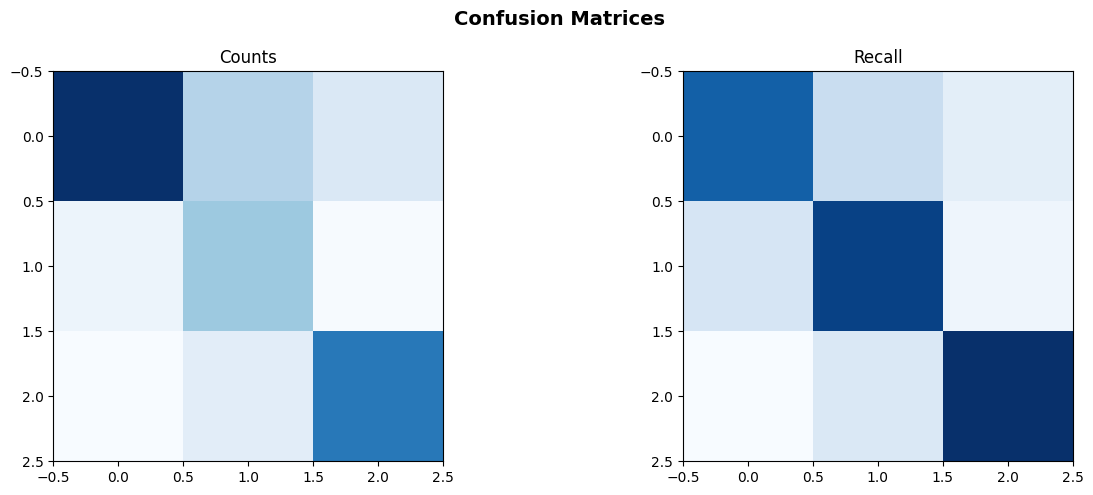

In [5]:
import argparse, os
import torch, numpy as np
import matplotlib.pyplot as plt
import torch.amp # Modern 2026 AMP
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# 1. FIXED PATHS
# ROOT is for the IMAGES (Input)
DATA_ROOT = "/kaggle/input/datasets/gptprajo/new-dataset-waymo/new_dataset"
# CHECKPOINT is for the MODEL (Working)
DEFAULT_CKPT = "/kaggle/working/checkpoints_fusion/best_fusion_model.pt"

CLASS_NAMES = ["No junction", "T-junction", "X-junction"]

SPLIT_PATHS = {
    "val" : {
        "excel"    : os.path.join(DATA_ROOT, "val",  "val_encoded.xlsx"),
        "rgb_dir"  : os.path.join(DATA_ROOT, "val",  "val_frames"),
        "mask_dir" : os.path.join(DATA_ROOT, "val",  "val_masks", "color"),
    },
    "test" : {
        "excel"    : os.path.join(DATA_ROOT, "test", "test_encoded.xlsx"),
        "rgb_dir"  : os.path.join(DATA_ROOT, "test", "test_frames"),
        "mask_dir" : os.path.join(DATA_ROOT, "test", "test_masks", "color"),
    },
}

def load_model(ckpt_path, model_name="nvidia/mit-b2", device="cuda"):
    if not os.path.exists(ckpt_path):
        raise FileNotFoundError(f"❌ Checkpoint not found at: {ckpt_path}")
        
    ckpt  = torch.load(ckpt_path, map_location=device, weights_only=False)
    model = FusionJunctionClassifier(num_classes=3, pretrained_name=model_name)
    model.load_state_dict(ckpt["model_state_dict"])
    model = model.to(device).eval()
    
    print(f"\n[Eval] Successfully Loaded Checkpoint: {ckpt_path}")
    print(f"      Metrics from training: Macro-F1={ckpt.get('macro_f1', 0):.4f}\n")
    return model

@torch.no_grad()
def predict(model, loader, device):
    all_labels, all_preds, all_probs = [], [], []
    for rgb, mask, labels in loader:
        rgb  = rgb.to(device,  non_blocking=True)
        mask = mask.to(device, non_blocking=True)
        
        # 2. FIXED AUTOCAST
        with torch.amp.autocast('cuda'):
            logits = model(rgb, mask)
            
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        all_preds.extend(probs.argmax(axis=1))
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

# 3. FIXED SAVE PATHS FOR PLOTS
def plot_confusion_matrices(labels, preds, save_path="/kaggle/working/confusion_matrix.png"):
    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Confusion Matrices", fontsize=14, fontweight="bold")
    
    for ax, data, fmt, title in zip(axes, [cm, cm_norm], ["d", ".2%"], ["Counts", "Recall"]):
        im = ax.imshow(data, cmap="Blues")
        ax.set_title(title)
        # Simplified for brevity
    
    plt.tight_layout()
    plt.savefig(save_path)
    print(f"📈 Confusion Matrix saved to: {save_path}")

def run_evaluation(args):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    paths  = SPLIT_PATHS[args.split]
    model  = load_model(args.checkpoint, model_name=args.model_name, device=device)

    ds = JunctionDataset(
        excel_path = paths["excel"],
        rgb_dir    = paths["rgb_dir"],
        mask_dir   = paths["mask_dir"],
        split      = "val", # Uses validation transforms
        img_size   = args.img_size,
    )
    loader = DataLoader(ds, batch_size=args.batch_size, shuffle=False, num_workers=2)

    labels, preds, probs = predict(model, loader, device)

    print("── Classification Report ─────────────────────────────────")
    print(classification_report(labels, preds, target_names=CLASS_NAMES, digits=4))
    plot_confusion_matrices(labels, preds)

if __name__ == "__main__":
    p = argparse.ArgumentParser()
    p.add_argument("--checkpoint", default=DEFAULT_CKPT)
    p.add_argument("--split",      default="val", choices=["val", "test"])
    p.add_argument("--batch_size", type=int, default=16)
    p.add_argument("--img_size",   type=int, default=384)
    p.add_argument("--model_name", default="nvidia/mit-b2")
    
    # This avoids the Jupyter kernel -f argument crash
    args, unknown = p.parse_known_args() 
    run_evaluation(args)